### Base line of machine learning model



In [2]:
from sklearn.linear_model import LogisticRegression
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
DADOS_INTERIM = Path.cwd().parent / 'data' / 'interim'

X_train = pd.read_parquet(DADOS_INTERIM / 'X_train.parquet')
y_train = pd.read_parquet(DADOS_INTERIM / 'y_train.parquet').squeeze('columns')

X_val = pd.read_parquet(DADOS_INTERIM / 'X_val.parquet')
y_val = pd.read_parquet(DADOS_INTERIM / 'y_val.parquet').squeeze('columns')

X_test = pd.read_parquet(DADOS_INTERIM / 'X_test.parquet')
y_test = pd.read_parquet(DADOS_INTERIM / 'y_test.parquet').squeeze('columns')

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape} | y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape} | y_test:  {y_test.shape}')

X_train: (196806, 146) | y_train: (196806,)
X_val:   (49202, 146) | y_val:   (49202,)
X_test:  (61503, 146) | y_test:  (61503,)


In [7]:
import numpy as np

CATEGORICAS_FORCADAS = []
NUMERICAS_FORCADAS = []

def separar_variaveis(df, categoricas_forcadas=None, numericas_forcadas=None):
    """Retorna listas mutuamente exclusivas de colunas categóricas e numéricas."""
    categoricas_forcadas = set(categoricas_forcadas or [])
    numericas_forcadas = set(numericas_forcadas or [])

    colunas_invalidas = (categoricas_forcadas | numericas_forcadas) - set(df.columns)
    if colunas_invalidas:
        raise KeyError(f'Colunas não encontradas: {sorted(colunas_invalidas)}')
    if categoricas_forcadas & numericas_forcadas:
        raise ValueError('Uma coluna não pode ser forçada como categórica e numérica ao mesmo tempo.')

    categoricas = set(
        df.select_dtypes(include=['object', 'string', 'category', 'bool']).columns
    )
    numericas = set(df.select_dtypes(include=[np.number]).columns)

    categoricas = (categoricas - numericas_forcadas) | categoricas_forcadas
    numericas = (numericas - categoricas_forcadas) | numericas_forcadas

    nao_classificadas = set(df.columns) - categoricas - numericas
    if nao_classificadas:
        raise TypeError(
            'Há colunas com dtype não classificado. Defina-as em uma das listas de exceção: '
            f'{sorted(nao_classificadas)}'
        )

    categoricas = sorted(categoricas)
    numericas = sorted(numericas)

    assert not (set(categoricas) & set(numericas))
    assert set(categoricas) | set(numericas) == set(df.columns)
    return categoricas, numericas

variaveis_categoricas, variaveis_numericas = separar_variaveis(
    X_train,
    categoricas_forcadas=CATEGORICAS_FORCADAS,
    numericas_forcadas=NUMERICAS_FORCADAS,
)

print(f'Variáveis categóricas: {len(variaveis_categoricas)}')
print(f'Variáveis numéricas: {len(variaveis_numericas)}')
print('Total de colunas classificadas:', len(variaveis_categoricas) + len(variaveis_numericas))

Variáveis categóricas: 15
Variáveis numéricas: 131
Total de colunas classificadas: 146


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler


def criar_preprocessador(variaveis_numericas, variaveis_categoricas):
    """Create the preprocessing pipeline."""

    pipeline_numerico = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    pipeline_categorico = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])

    preprocessador = ColumnTransformer(
        transformers=[
            ("numericas", pipeline_numerico, variaveis_numericas),
            ("categoricas", pipeline_categorico, variaveis_categoricas),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    ).set_output(transform="pandas")

    return preprocessador

In [8]:
preprocessador = criar_preprocessador(
    variaveis_numericas=variaveis_numericas,
    variaveis_categoricas=variaveis_categoricas,
)

X_train_processado = preprocessador.fit_transform(X_train)
X_val_processado = preprocessador.transform(X_val)
X_test_processado = preprocessador.transform(X_test)

In [10]:
melhores_variaveis = [
    "BENS_RENDA_RATIO",
    "LIMITE_TOTAL",
    "TOTAL_PARCELAS",
    "REG_CITY_NOT_LIVE_CITY",
    "CONTATOS_POR_CREDITO",
    "CNT_FAM_MEMBERS",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "FLAG_DOCUMENT_3",
    "AREA_CONSTRUIDA_TOTAL",
    "REGION_POPULATION_RELATIVE",
    "QUALIDADE_MORADIA",
    "HISTORICO_FINANCEIRO_TOTAL",
    "EXT_SOURCE_2",
    "ATRASO_POR_PARCELA",
    "ORGANIZATION_TYPE",
    "TEMPO_CADASTRO_ANOS",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "HISTORICO_MESES",
    "CREDITOS_POR_IDADE",
    "UTILIZACAO_LIMITE_BUREAU",
    "EXT_SOURCE_MAX",
    "PCT_CREDITOS_ATIVOS",
    "NAME_INCOME_TYPE",
    "DOCUMENTOS_POR_CREDITO",
    "NAME_FAMILY_STATUS",
    "FLAG_WORK_PHONE",
    "TEMPO_DOCUMENTO_ANOS",
    "PAGAMENTO_SALDO_RATIO",
    "CREDITO_NEGADO_TOTAL",
    "VALOR_CREDITO_TOTAL",
    "DIAS_CREDITO_MEDIO",
    "ATRASO_PAGAMENTO_MAX",
    "TOTAL_FLAGS_DOCUMENTOS",
    "TEMPO_CREDITO_POR_IDADE",
    "REGION_RATING_CLIENT_W_CITY",
    "DIVIDA_TOTAL",
    "CREDITO_APROVADO_RENDA",
    "SOLICITACOES_POR_EMPREGO",
    "CREDITO_ATIVO",
    "AMT_CREDIT",
    "TEMPO_EMPREGADO_ANOS",
    "VALOR_CREDITO_MEDIO_BUREAU",
    "OCCUPATION_TYPE",
    "SAQUE_LIMITE_RATIO",
    "VALOR_MEDIO_PARCELA",
    "ANUIDADE_MEDIA",
    "DIAS_DECISAO_MEDIO",
    "DPD_DEF_MEDIO_POS",
    "UTILIZACAO_CARTAO",
    "OWN_CAR_AGE",
    "EXT_SOURCE_COMPLT_SUM",
    "TAXA_APROVACAO_CREDITO",
    "DIVIDA_RENDA_RATIO",
    "ANUIDADE_HISTORICA_RATIO",
    "EXT_SOURCE_1",
    "NAME_EDUCATION_TYPE",
    "CREDITO_APROVADO_TOTAL",
    "TOTAL_POS",
    "VALOR_PAGO_TOTAL",
    "EXT_SOURCE_MIN",
    "CREDITO_VS_BEM_RATIO",
    "AMT_ANNUITY",
    "EXT_SOURCE_3",
    "IDADE_ANOS",
    "PCT_PAGAMENTO_REALIZADO",
    "AMT_GOODS_PRICE",
    "EXT_SOURCE_COMPLT_MEAN",
]

In [11]:
X_train_processado = X_train_processado[melhores_variaveis]
X_val_processado = X_val_processado[melhores_variaveis]
X_test_processado = X_test_processado[melhores_variaveis]

In [ ]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
)


def calcular_metricas(y_true, y_pred, y_prob):
    """Calcula as métricas de classificação."""

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ks = (tpr - fpr).max()

    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1_SCORE": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob),
        "KS": ks,
    }

modelo_regressao_logistica = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    solver="liblinear",
    random_state=42,
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

y_prob_cv = cross_val_predict(
    estimator=modelo_regressao_logistica,
    X=X_train_processado,
    y=y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

y_pred_cv = (y_prob_cv >= 0.5).astype(int)

metricas_regressao_logistica = calcular_metricas(
    y_true=y_train,
    y_pred=y_pred_cv,
    y_prob=y_prob_cv,
)

resumo_regressao_logistica = pd.DataFrame(
    [metricas_regressao_logistica],
    index=["Regressão Logística"],
).round(4)

display(resumo_regressao_logistica)

,Precision,Recall,F1_SCORE,ROC_AUC,PR_AUC,KS
Regressão Logística,0.1632,0.6871,0.2638,0.7536,0.2325,0.3807


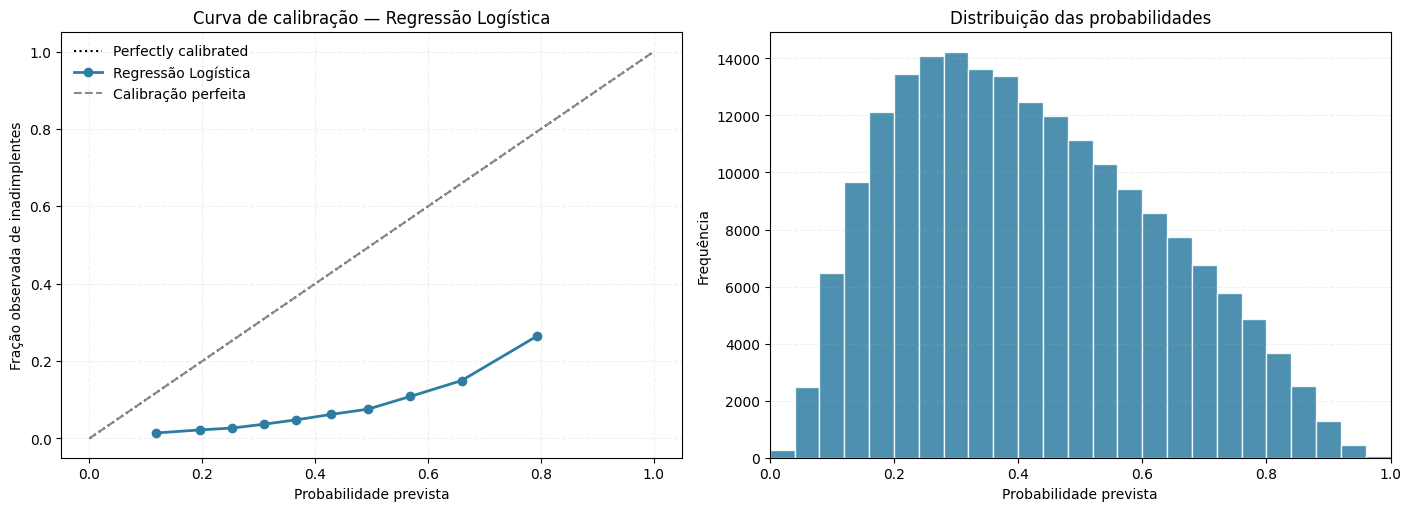

Brier Score OOF: 0.20115


In [14]:
import matplotlib.pyplot as plt

from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss


brier_regressao_logistica = brier_score_loss(y_train, y_prob_cv)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5),
    constrained_layout=True,
)

CalibrationDisplay.from_predictions(
    y_true=y_train,
    y_prob=y_prob_cv,
    n_bins=10,
    strategy="quantile",
    name="Regressão Logística",
    color="#2E7DA1",
    marker="o",
    markersize=6,
    linewidth=2,
    ax=axes[0],
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#8A8A8A",
    linewidth=1.5,
    label="Calibração perfeita",
)

axes[0].set_title("Curva de calibração — Regressão Logística", fontweight="normal")
axes[0].set_xlabel("Probabilidade prevista")
axes[0].set_ylabel("Fração observada de inadimplentes")
axes[0].grid(linestyle="--", alpha=0.20)
axes[0].legend(frameon=False)

axes[1].hist(
    y_prob_cv,
    bins=25,
    range=(0, 1),
    color="#2E7DA1",
    alpha=0.85,
    edgecolor="white",
)

axes[1].set_title("Distribuição das probabilidades", fontweight="normal")
axes[1].set_xlabel("Probabilidade prevista")
axes[1].set_ylabel("Frequência")
axes[1].set_xlim(0, 1)
axes[1].grid(axis="y", linestyle="--", alpha=0.20)
axes[1].grid(axis="x", visible=False)

plt.show()

print(f"Brier Score OOF: {brier_regressao_logistica:.5f}")

In [15]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss


modelo_regressao_logistica_final = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    solver="liblinear",
    random_state=42,
)

modelo_regressao_logistica_final.fit(
    X_train_processado,
    y_train,
)

y_prob_test_lr = modelo_regressao_logistica_final.predict_proba(
    X_test_processado,
)[:, 1]

y_pred_test_lr = (y_prob_test_lr >= 0.5).astype(int)

metricas_teste_regressao_logistica = calcular_metricas(
    y_true=y_test,
    y_pred=y_pred_test_lr,
    y_prob=y_prob_test_lr,
)

metricas_teste_regressao_logistica["Brier Score"] = brier_score_loss(
    y_test,
    y_prob_test_lr,
)

resultado_teste_regressao_logistica = pd.DataFrame(
    [metricas_teste_regressao_logistica],
    index=["Regressão Logística"],
).round(4)

display(resultado_teste_regressao_logistica)

,Precision,Recall,F1_SCORE,ROC_AUC,PR_AUC,KS,Brier Score
Regressão Logística,0.165,0.6904,0.2664,0.7569,0.2415,0.3867,0.1999
